In [2]:
import pandas as pd

In [4]:
df = pd.read_csv("../data/retail_sales_raw.csv", encoding="latin1")

In [5]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


# Analyse exploratoire des ventes retail

## Objectif du projet

L’objectif de ce projet est d’analyser les ventes d’un magasin retail afin d’identifier les produits les plus performants, les périodes les plus rentables, les catégories générant le plus de chiffre d’affaires et les segments clients les plus intéressants.

## 1. Chargement et première exploration des données


In [89]:
df.shape

(9994, 21)

In [90]:
df.columns.tolist()

['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Customer Name',
 'Segment',
 'Country',
 'City',
 'State',
 'Postal Code',
 'Region',
 'Product ID',
 'Category',
 'Sub-Category',
 'Product Name',
 'Sales',
 'Quantity',
 'Discount',
 'Profit']

In [91]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

### Premières observations

Le dataset contient 9 994 lignes et 21 colonnes.  
Chaque ligne semble représenter un produit vendu au sein d'une commande, car un même identifiant de commande peut apparaître sur plusieurs lignes.

Les variables disponibles couvrent plusieurs dimensions :
- les commandes ;
- les clients ;
- les produits ;
- la géographie ;
- les indicateurs commerciaux.

Les colonnes `Order Date` et `Ship Date` sont actuellement au format texte et devront être converties en dates pour permettre une analyse temporelle des ventes.

In [92]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [93]:
df.duplicated().sum()

np.int64(0)

In [94]:
print("Nombre de lignes :", len(df))
print("Nombre de commandes uniques :", df["Order ID"].nunique())
print("Nombre de clients uniques :", df["Customer ID"].nunique())
print("Nombre de produits uniques :", df["Product ID"].nunique())

Nombre de lignes : 9994
Nombre de commandes uniques : 5009
Nombre de clients uniques : 793
Nombre de produits uniques : 1862


### Qualité initiale des données

Le dataset ne contient aucune valeur manquante et aucune ligne strictement dupliquée.

Il comprend :
- 9 994 lignes de vente ;
- 5 009 commandes uniques ;
- 793 clients uniques ;
- 1 862 produits uniques.

La différence entre le nombre de lignes et le nombre de commandes s’explique par le fait qu’une même commande peut contenir plusieurs produits. Chaque ligne représente donc un article vendu au sein d’une commande.

In [95]:
df[["Sales", "Quantity", "Discount", "Profit"]].describe()

,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,3.789574,0.156203,28.656896
std,623.245101,2.225110,0.206452,234.260108
min,0.444000,1.000000,0.000000,-6599.978000
25%,17.280000,2.000000,0.000000,1.728750
50%,54.490000,3.000000,0.200000,8.666500
75%,209.940000,5.000000,0.200000,29.364000
max,22638.480000,14.000000,0.800000,8399.976000


### Premiers constats sur les variables numériques

L'analyse descriptive montre que le montant moyen des ventes par ligne est de 229,86, alors que la médiane est de 54,49. Cette différence suggère la présence de quelques ventes très élevées qui tirent la moyenne vers le haut.

La quantité moyenne vendue est d'environ 3,8 articles par ligne de commande.

Le taux de remise moyen est de 15,6 %, avec certaines remises pouvant atteindre 80 %.

Enfin, le profit varie fortement, de -6 599,98 à 8 399,98, ce qui indique que certaines ventes génèrent des pertes importantes. Une analyse complémentaire de la rentabilité pourra donc être pertinente.

In [96]:
df_clean = df.copy()

In [97]:
df_clean["Order Date"] = pd.to_datetime(df_clean["Order Date"], format="%m/%d/%Y")
df_clean["Ship Date"] = pd.to_datetime(df_clean["Ship Date"], format="%m/%d/%Y")

In [98]:
df_clean[["Order Date", "Ship Date"]].dtypes

Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object

In [99]:
df_clean["Order Year"] = df_clean["Order Date"].dt.year
df_clean["Order Month"] = df_clean["Order Date"].dt.month
df_clean["Order Month Name"] = df_clean["Order Date"].dt.month_name()
df_clean["Order Quarter"] = df_clean["Order Date"].dt.quarter

In [100]:
df_clean[[
    "Order Date",
    "Order Year",
    "Order Month",
    "Order Month Name",
    "Order Quarter"
]].head()

,Order Date,Order Year,Order Month,Order Month Name,Order Quarter
0,2016-11-08,2016,11,November,4
1,2016-11-08,2016,11,November,4
2,2016-06-12,2016,6,June,2
3,2015-10-11,2015,10,October,4
4,2015-10-11,2015,10,October,4


### Préparation des données

Les colonnes `Order Date` et `Ship Date` ont été converties au format date afin de permettre les analyses temporelles.

À partir de la date de commande, de nouvelles variables ont été créées :
- l'année de commande ;
- le numéro du mois ;
- le nom du mois ;
- le trimestre.

Ces variables permettront d'analyser l'évolution des ventes par année, par mois et par trimestre.

In [101]:
df_clean.to_csv("../data/retail_sales_clean.csv", index=False)

In [102]:
total_sales = df_clean["Sales"].sum()
total_orders = df_clean["Order ID"].nunique()
total_customers = df_clean["Customer ID"].nunique()
total_quantity = df_clean["Quantity"].sum()
average_order_value = total_sales / total_orders
total_profit = df_clean["Profit"].sum()
profit_margin = total_profit / total_sales

In [103]:
kpis = pd.DataFrame({
    "Indicateur": [
        "Chiffre d'affaires total",
        "Nombre de commandes",
        "Nombre de clients",
        "Quantité totale vendue",
        "Panier moyen",
        "Profit total",
        "Marge globale"
    ],
    "Valeur": [
        total_sales,
        total_orders,
        total_customers,
        total_quantity,
        average_order_value,
        total_profit,
        profit_margin
    ]
})

kpis

,Indicateur,Valeur
0,Chiffre d'affaires total,2.297201e+06
1,Nombre de commandes,5.009000e+03
2,Nombre de clients,7.930000e+02
3,Quantité totale vendue,3.787300e+04
4,Panier moyen,4.586147e+02
5,Profit total,2.863970e+05
6,Marge globale,1.246722e-01


In [104]:
def formater_kpi(row):
    if row["Indicateur"] in [
        "Chiffre d'affaires total",
        "Panier moyen",
        "Profit total"
    ]:
        return f"{row['Valeur']:,.2f} $"
    
    elif row["Indicateur"] == "Marge globale":
        return f"{row['Valeur']:.2%}"
    
    else:
        return f"{int(row['Valeur']):,}".replace(",", " ")

kpis_display = kpis.copy()
kpis_display["Valeur"] = kpis_display.apply(formater_kpi, axis=1)

kpis_display

,Indicateur,Valeur
0,Chiffre d'affaires total,"2,297,200.86 $"
1,Nombre de commandes,5 009
2,Nombre de clients,793
3,Quantité totale vendue,37 873
4,Panier moyen,458.61 $
5,Profit total,"286,397.02 $"
6,Marge globale,12.47%


### Analyse des KPIs globaux

Sur la période étudiée, le magasin a généré un chiffre d'affaires total de 2,30 millions de dollars pour 5 009 commandes distinctes et 793 clients.

Le panier moyen s'élève à 458,61 $, ce qui signifie qu'une commande rapporte en moyenne près de 459 $.

Le profit total atteint 286 397,02 $, soit une marge globale de 12,47 %. Le magasin est donc rentable dans l'ensemble, mais l'analyse descriptive précédente a montré que certaines ventes génèrent des pertes importantes. Il sera donc utile d'étudier plus tard la rentabilité par catégorie ou sous-catégorie.

## 3. Analyse des produits

### 3.1 Produits générant le plus de chiffre d'affaires

In [105]:
top_products_sales = (
    df_clean
    .groupby("Product Name", as_index=False)["Sales"]
    .sum()
    .sort_values(by="Sales", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

top_products_sales

,Product Name,Sales
0,Canon imageCLASS 2200 Advanced Copier,61599.824
1,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.384
2,Cisco TelePresence System EX90 Videoconferenci...,22638.480
3,HON 5400 Series Task Chairs for Big and Tall,21870.576
4,GBC DocuBind TL300 Electric Binding System,19823.479
5,GBC Ibimaster 500 Manual ProClick Binding System,19024.500
6,Hewlett Packard LaserJet 3310 Copier,18839.686
7,HP Designjet T520 Inkjet Large Format Printer ...,18374.895
8,GBC DocuBind P400 Electric Binding System,17965.068
9,High Speed Automatic Electric Letter Opener,17030.312


### 3.2 Produits les plus vendus en quantité

In [106]:
top_products_quantity = (
    df_clean
    .groupby("Product Name", as_index=False)["Quantity"]
    .sum()
    .sort_values(by="Quantity", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

top_products_quantity

,Product Name,Quantity
0,Staples,215
1,Staple envelope,170
2,Easy-staple paper,150
3,Staples in misc. colors,86
4,KI Adjustable-Height Table,74
5,Storex Dura Pro Binders,71
6,Avery Non-Stick Binders,71
7,GBC Premium Transparent Covers with Diagonal L...,67
8,"Situations Contoured Folding Chairs, 4/Set",64
9,Staple-based wall hangings,62


### Analyse des produits

Les produits qui génèrent le plus de chiffre d'affaires sont principalement des équipements à forte valeur unitaire, comme des copieurs, des systèmes de visioconférence ou des imprimantes.

À l'inverse, les produits les plus vendus en quantité sont surtout des fournitures de bureau, comme les agrafes, enveloppes et papiers.

Cette différence montre qu'un produit très vendu en volume n'est pas nécessairement celui qui contribue le plus au chiffre d'affaires. Il est donc important de distinguer la performance en valeur et la performance en volume.

In [107]:
import matplotlib.pyplot as plt

### 3.3 Visualisation des produits les plus performants

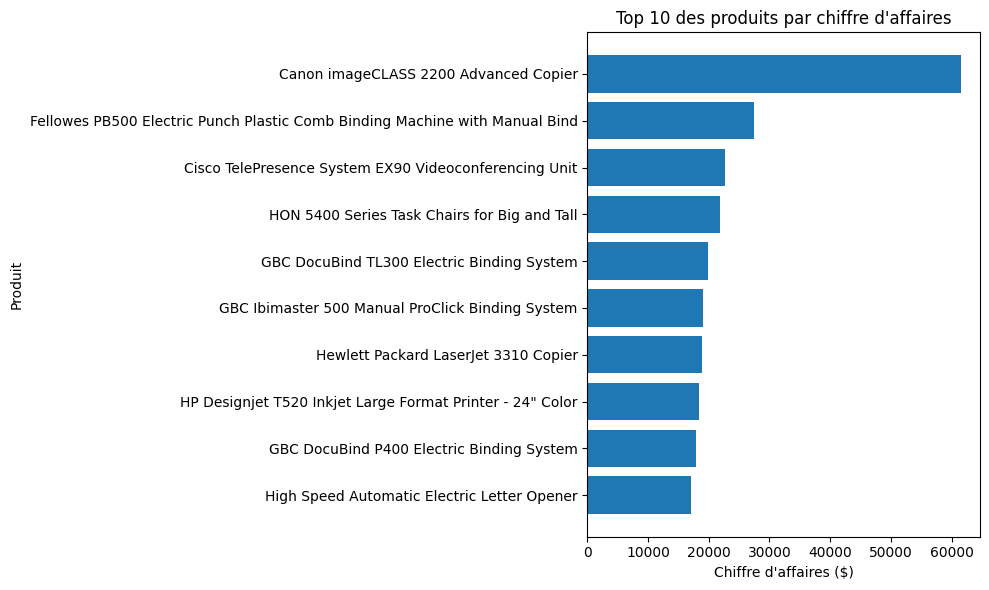

In [108]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_products_sales["Product Name"],
    top_products_sales["Sales"]
)

plt.title("Top 10 des produits par chiffre d'affaires")
plt.xlabel("Chiffre d'affaires ($)")
plt.ylabel("Produit")

plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig("../outputs/figures/top_10_products_sales.png", dpi=300, bbox_inches="tight")

plt.show()

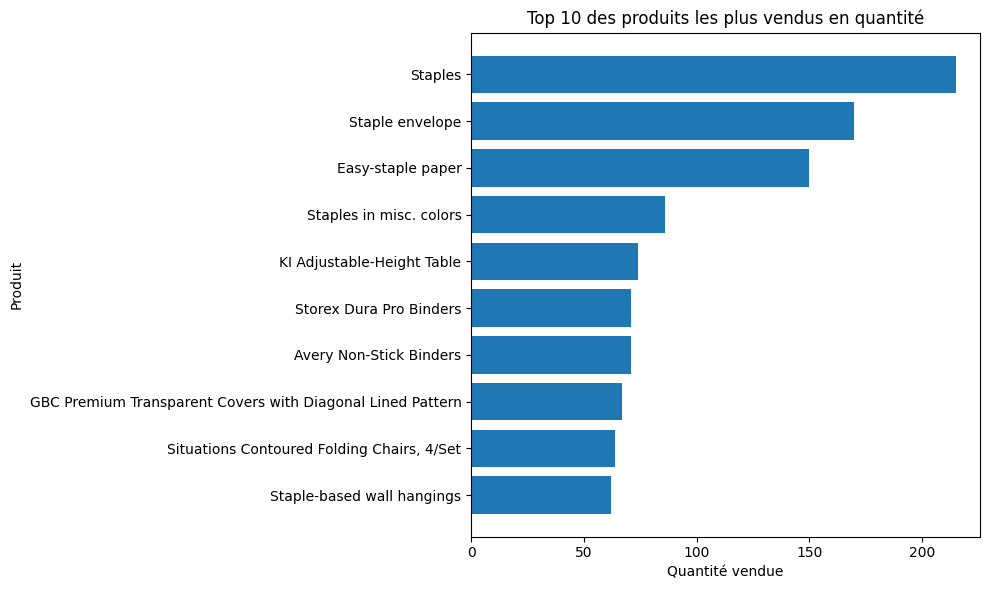

In [109]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_products_quantity["Product Name"],
    top_products_quantity["Quantity"]
)

plt.title("Top 10 des produits les plus vendus en quantité")
plt.xlabel("Quantité vendue")
plt.ylabel("Produit")

plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig("../outputs/figures/top_10_products_quantity.png", dpi=300, bbox_inches="tight")

plt.show()

## 4. Analyse temporelle des ventes

### 4.1 Évolution du chiffre d'affaires par année

In [110]:
sales_by_year = (
    df_clean
    .groupby("Order Year", as_index=False)["Sales"]
    .sum()
    .sort_values("Order Year")
)

sales_by_year

,Order Year,Sales
0,2014,484247.4981
1,2015,470532.5090
2,2016,609205.5980
3,2017,733215.2552


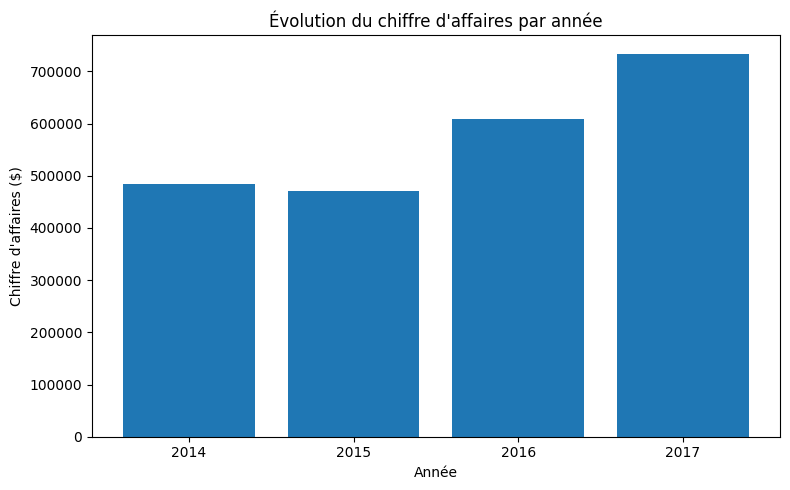

In [111]:
plt.figure(figsize=(8, 5))

plt.bar(
    sales_by_year["Order Year"],
    sales_by_year["Sales"]
)

plt.title("Évolution du chiffre d'affaires par année")
plt.xlabel("Année")
plt.ylabel("Chiffre d'affaires ($)")
plt.xticks(sales_by_year["Order Year"])

plt.tight_layout()
plt.savefig("../outputs/figures/sales_by_year.png", dpi=300, bbox_inches="tight")
plt.show()

### 4.2 Ventes cumulées par mois

In [112]:
sales_by_month = (
    df_clean
    .groupby(["Order Month", "Order Month Name"], as_index=False)["Sales"]
    .sum()
    .sort_values("Order Month")
)

sales_by_month

,Order Month,Order Month Name,Sales
0,1,January,94924.8356
1,2,February,59751.2514
2,3,March,205005.4888
3,4,April,137762.1286
4,5,May,155028.8117
5,6,June,152718.6793
6,7,July,147238.0970
7,8,August,159044.0630
8,9,September,307649.9457
9,10,October,200322.9847


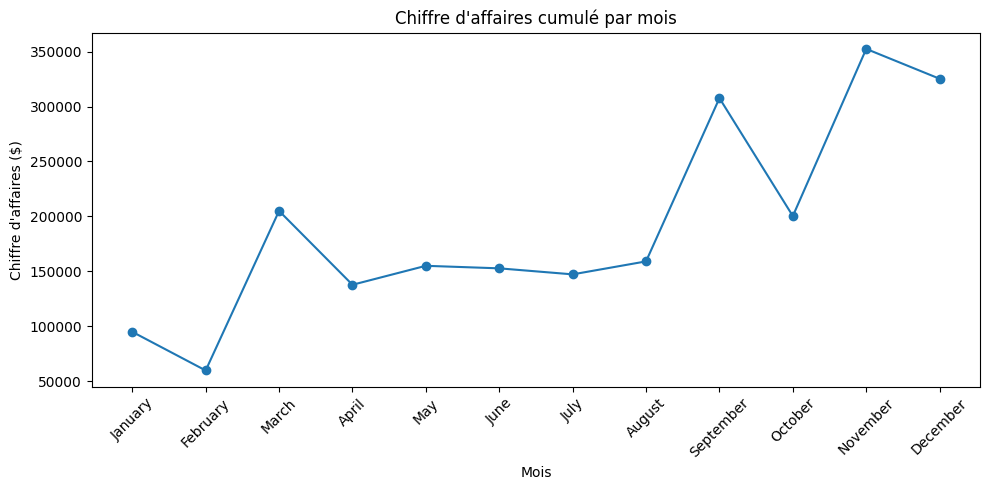

In [113]:
plt.figure(figsize=(10, 5))

plt.plot(
    sales_by_month["Order Month Name"],
    sales_by_month["Sales"],
    marker="o"
)

plt.title("Chiffre d'affaires cumulé par mois")
plt.xlabel("Mois")
plt.ylabel("Chiffre d'affaires ($)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("../outputs/figures/sales_by_month.png", dpi=300, bbox_inches="tight")
plt.show()

In [114]:
df_clean["Order Year-Month"] = df_clean["Order Date"].dt.to_period("M").astype(str)

In [115]:
sales_by_year_month = (
    df_clean
    .groupby("Order Year-Month", as_index=False)["Sales"]
    .sum()
    .sort_values("Order Year-Month")
)

sales_by_year_month.head()

,Order Year-Month,Sales
0,2014-01,14236.895
1,2014-02,4519.892
2,2014-03,55691.009
3,2014-04,28295.345
4,2014-05,23648.287


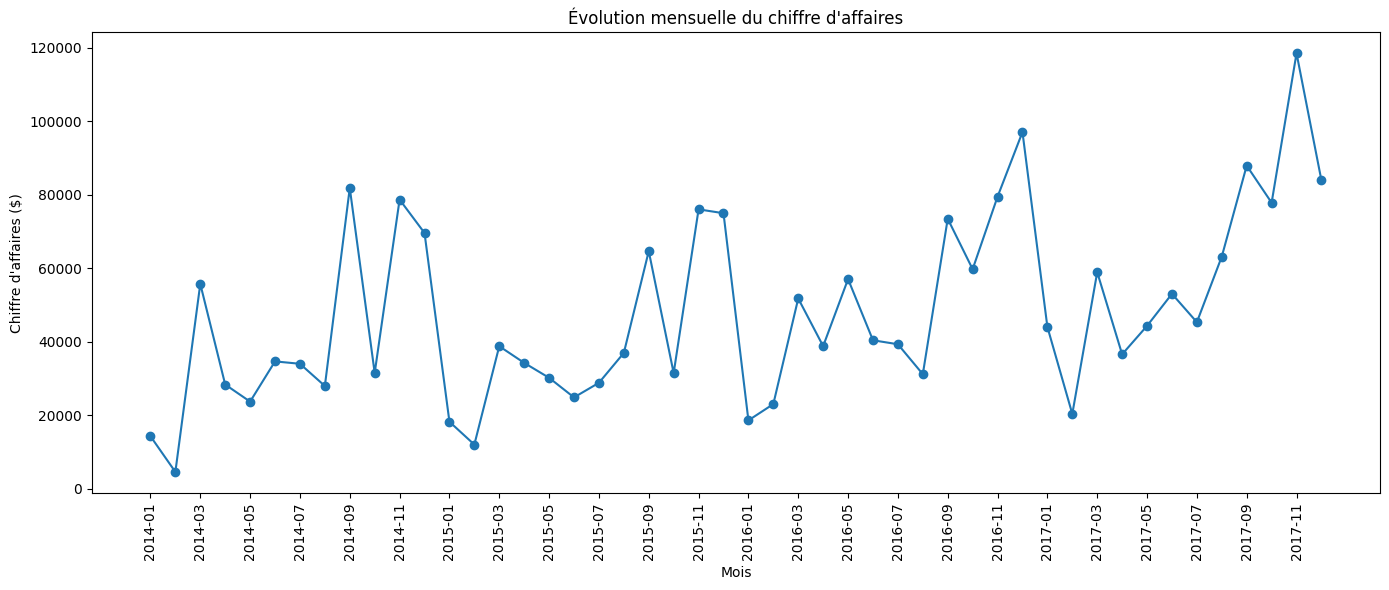

In [116]:
plt.figure(figsize=(14, 6))

plt.plot(
    sales_by_year_month["Order Year-Month"],
    sales_by_year_month["Sales"],
    marker="o"
)

plt.title("Évolution mensuelle du chiffre d'affaires")
plt.xlabel("Mois")
plt.ylabel("Chiffre d'affaires ($)")
plt.xticks( ticks=range(0, len(sales_by_year_month), 2),
    labels=sales_by_year_month["Order Year-Month"][::2],
    rotation=90)

plt.tight_layout()
plt.savefig("../outputs/figures/sales_by_year_month.png", dpi=300, bbox_inches="tight")
plt.show()

### Analyse temporelle

Le chiffre d'affaires évolue globalement à la hausse sur la période étudiée. Après une légère baisse entre 2014 et 2015, les ventes progressent nettement en 2016 puis atteignent leur niveau le plus élevé en 2017.

L'analyse cumulée par mois montre une saisonnalité marquée. Les mois de novembre, décembre et septembre sont les plus performants, tandis que février est le mois le plus faible.

L'évolution mensuelle complète confirme cette tendance : les pics de ventes apparaissent régulièrement en fin d'année et deviennent globalement plus élevés au fil du temps.

## 5. Analyse des catégories

### 5.1 Chiffre d'affaires et profit par catégorie

In [117]:
category_performance = (
    df_clean
    .groupby("Category", as_index=False)
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Quantity=("Quantity", "sum")
    )
    .sort_values(by="Sales", ascending=False)
)

category_performance

,Category,Sales,Profit,Quantity
2,Technology,836154.0330,145454.9481,6939
0,Furniture,741999.7953,18451.2728,8028
1,Office Supplies,719047.0320,122490.8008,22906


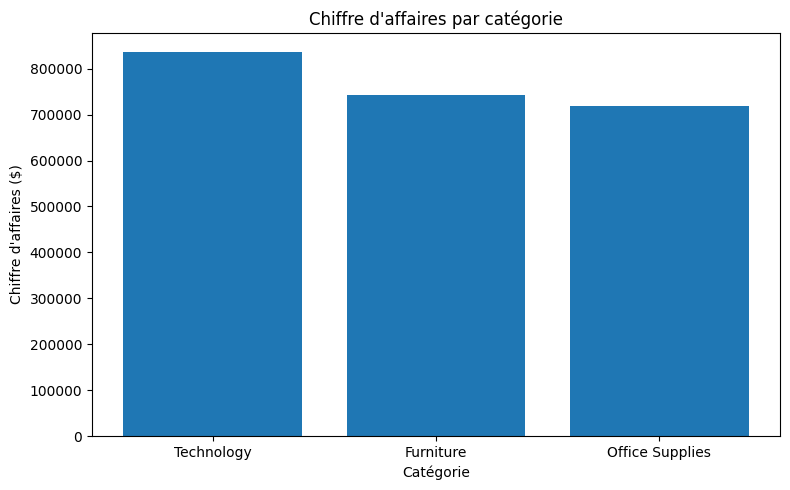

In [118]:
plt.figure(figsize=(8, 5))

plt.bar(
    category_performance["Category"],
    category_performance["Sales"]
)

plt.title("Chiffre d'affaires par catégorie")
plt.xlabel("Catégorie")
plt.ylabel("Chiffre d'affaires ($)")

plt.tight_layout()
plt.savefig("../outputs/figures/sales_by_category.png", dpi=300, bbox_inches="tight")
plt.show()

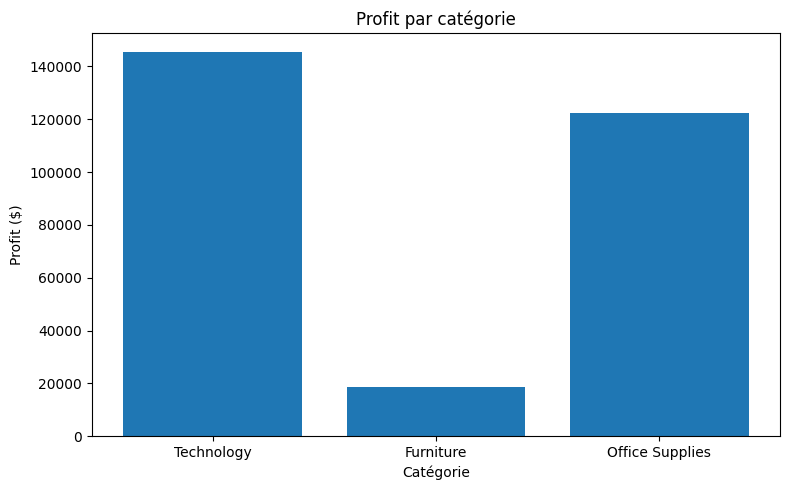

In [119]:
plt.figure(figsize=(8, 5))

plt.bar(
    category_performance["Category"],
    category_performance["Profit"]
)

plt.title("Profit par catégorie")
plt.xlabel("Catégorie")
plt.ylabel("Profit ($)")

plt.tight_layout()
plt.savefig("../outputs/figures/profit_by_category.png", dpi=300, bbox_inches="tight")
plt.show()

### Analyse des catégories

La catégorie `Technology` est celle qui génère le plus de chiffre d'affaires et également le plus de profit.

La catégorie `Furniture` réalise un chiffre d'affaires élevé, proche de celui de `Office Supplies`, mais son profit est très faible en comparaison. Cela montre qu'une forte performance commerciale en chiffre d'affaires ne signifie pas nécessairement une bonne rentabilité.

À l'inverse, `Office Supplies` génère un chiffre d'affaires légèrement inférieur à `Furniture`, mais un profit nettement supérieur. Il est donc important d'analyser à la fois les ventes et la rentabilité.

In [120]:
category_performance["Margin"] = (
    category_performance["Profit"] / category_performance["Sales"]
)

category_performance

,Category,Sales,Profit,Quantity,Margin
2,Technology,836154.0330,145454.9481,6939,0.173957
0,Furniture,741999.7953,18451.2728,8028,0.024867
1,Office Supplies,719047.0320,122490.8008,22906,0.170352


In [121]:
category_display = category_performance.copy()

category_display["Sales"] = category_display["Sales"].map(lambda x: f"{x:,.2f} $")
category_display["Profit"] = category_display["Profit"].map(lambda x: f"{x:,.2f} $")
category_display["Margin"] = category_display["Margin"].map(lambda x: f"{x:.2%}")

category_display

,Category,Sales,Profit,Quantity,Margin
2,Technology,"836,154.03 $","145,454.95 $",6939,17.40%
0,Furniture,"741,999.80 $","18,451.27 $",8028,2.49%
1,Office Supplies,"719,047.03 $","122,490.80 $",22906,17.04%


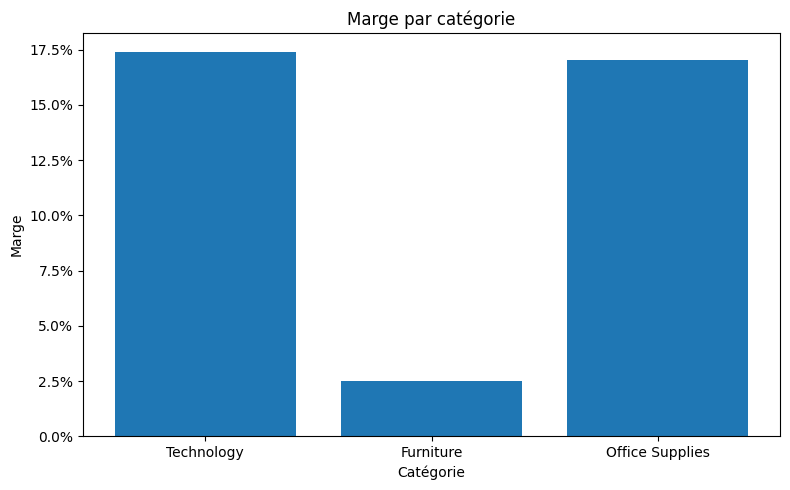

In [122]:
from matplotlib.ticker import PercentFormatter

plt.figure(figsize=(8, 5))

plt.bar(
    category_performance["Category"],
    category_performance["Margin"]
)

plt.title("Marge par catégorie")
plt.xlabel("Catégorie")
plt.ylabel("Marge")

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))

plt.tight_layout()
plt.savefig("../outputs/figures/margin_by_category.png", dpi=300, bbox_inches="tight")
plt.show()

### Analyse de la marge par catégorie

L'analyse de la marge confirme que les catégories `Technology` et `Office Supplies` sont les plus rentables, avec une marge proche de 17 %.

La catégorie `Furniture`, malgré un chiffre d'affaires élevé, affiche une marge très faible, autour de 2,5 %. Cela signifie qu'elle vend beaucoup, mais qu'elle génère peu de bénéfice proportionnellement à ses ventes.

Cette observation justifie une analyse plus détaillée des sous-catégories afin d'identifier les produits responsables de la faible rentabilité de `Furniture`.

### 5.2 Analyse des sous-catégories

In [123]:
subcategory_performance = (
    df_clean
    .groupby(["Category", "Sub-Category"], as_index=False)
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Quantity=("Quantity", "sum")
    )
)

subcategory_performance["Margin"] = (
    subcategory_performance["Profit"] / subcategory_performance["Sales"]
)

subcategory_performance.sort_values(by="Profit")

,Category,Sub-Category,Sales,Profit,Quantity,Margin
3,Furniture,Tables,206965.5320,-17725.4811,1241,-0.085645
0,Furniture,Bookcases,114879.9963,-3472.5560,868,-0.030228
12,Office Supplies,Supplies,46673.5380,-1189.0995,647,-0.025477
8,Office Supplies,Fasteners,3024.2800,949.5182,914,0.313965
15,Technology,Machines,189238.6310,3384.7569,440,0.017886
9,Office Supplies,Labels,12486.3120,5546.2540,1400,0.444187
5,Office Supplies,Art,27118.7920,6527.7870,3000,0.240711
7,Office Supplies,Envelopes,16476.4020,6964.1767,906,0.422676
2,Furniture,Furnishings,91705.1640,13059.1436,3563,0.142404
4,Office Supplies,Appliances,107532.1610,18138.0054,1729,0.168675


In [124]:
furniture_subcategories = (
    subcategory_performance[
        subcategory_performance["Category"] == "Furniture"
    ]
    .sort_values(by="Profit")
)

furniture_subcategories

,Category,Sub-Category,Sales,Profit,Quantity,Margin
3,Furniture,Tables,206965.5320,-17725.4811,1241,-0.085645
0,Furniture,Bookcases,114879.9963,-3472.5560,868,-0.030228
2,Furniture,Furnishings,91705.1640,13059.1436,3563,0.142404
1,Furniture,Chairs,328449.1030,26590.1663,2356,0.080957


In [125]:
furniture_display = furniture_subcategories.copy()

furniture_display["Sales"] = furniture_display["Sales"].map(lambda x: f"{x:,.2f} $")
furniture_display["Profit"] = furniture_display["Profit"].map(lambda x: f"{x:,.2f} $")
furniture_display["Margin"] = furniture_display["Margin"].map(lambda x: f"{x:.2%}")

furniture_display

,Category,Sub-Category,Sales,Profit,Quantity,Margin
3,Furniture,Tables,"206,965.53 $","-17,725.48 $",1241,-8.56%
0,Furniture,Bookcases,"114,880.00 $","-3,472.56 $",868,-3.02%
2,Furniture,Furnishings,"91,705.16 $","13,059.14 $",3563,14.24%
1,Furniture,Chairs,"328,449.10 $","26,590.17 $",2356,8.10%


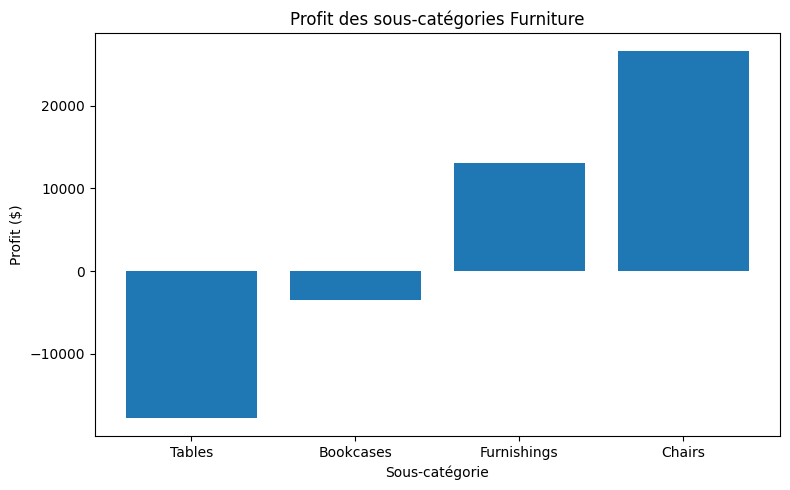

In [126]:
plt.figure(figsize=(8, 5))

plt.bar(
    furniture_subcategories["Sub-Category"],
    furniture_subcategories["Profit"]
)

plt.title("Profit des sous-catégories Furniture")
plt.xlabel("Sous-catégorie")
plt.ylabel("Profit ($)")

plt.tight_layout()
plt.savefig("../outputs/figures/profit_by_furniture_subcategory.png", dpi=300, bbox_inches="tight")
plt.show()

### Analyse des sous-catégories Furniture

L'analyse détaillée de la catégorie `Furniture` montre que sa faible rentabilité est principalement expliquée par deux sous-catégories déficitaires :

- `Tables`, avec un chiffre d'affaires de 206 965,53 $ mais une perte de 17 725,48 $, soit une marge de -8,56 % ;
- `Bookcases`, avec une perte de 3 472,56 $ et une marge de -3,02 %.

À l'inverse, `Chairs` et `Furnishings` restent rentables. La catégorie `Furniture` ne doit donc pas être considérée comme globalement non performante : ce sont surtout les sous-catégories `Tables` et `Bookcases` qui dégradent sa rentabilité.

### 5.3 Analyse des remises dans la catégorie Furniture

In [127]:
furniture_discount_analysis = (
    df_clean[df_clean["Category"] == "Furniture"]
    .groupby("Sub-Category", as_index=False)
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Average_Discount=("Discount", "mean")
    )
    .sort_values(by="Profit")
)

furniture_discount_analysis

,Sub-Category,Sales,Profit,Average_Discount
3,Tables,206965.5320,-17725.4811,0.261285
0,Bookcases,114879.9963,-3472.5560,0.211140
2,Furnishings,91705.1640,13059.1436,0.138349
1,Chairs,328449.1030,26590.1663,0.170178


In [128]:
furniture_discount_display = furniture_discount_analysis.copy()

furniture_discount_display["Sales"] = furniture_discount_display["Sales"].map(lambda x: f"{x:,.2f} $")
furniture_discount_display["Profit"] = furniture_discount_display["Profit"].map(lambda x: f"{x:,.2f} $")
furniture_discount_display["Average_Discount"] = furniture_discount_display["Average_Discount"].map(lambda x: f"{x:.2%}")

furniture_discount_display

,Sub-Category,Sales,Profit,Average_Discount
3,Tables,"206,965.53 $","-17,725.48 $",26.13%
0,Bookcases,"114,880.00 $","-3,472.56 $",21.11%
2,Furnishings,"91,705.16 $","13,059.14 $",13.83%
1,Chairs,"328,449.10 $","26,590.17 $",17.02%


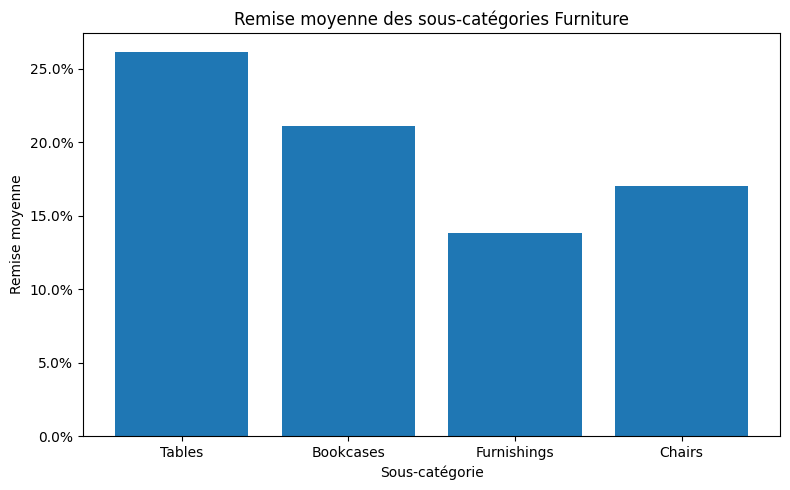

In [129]:
from matplotlib.ticker import PercentFormatter

plt.figure(figsize=(8, 5))

plt.bar(
    furniture_discount_analysis["Sub-Category"],
    furniture_discount_analysis["Average_Discount"]
)

plt.title("Remise moyenne des sous-catégories Furniture")
plt.xlabel("Sous-catégorie")
plt.ylabel("Remise moyenne")

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))

plt.tight_layout()
plt.savefig("../outputs/figures/average_discount_by_furniture_subcategory.png", dpi=300, bbox_inches="tight")
plt.show()

### Analyse des remises

Les sous-catégories déficitaires de `Furniture` sont également celles qui présentent les remises moyennes les plus élevées :

- `Tables` affiche une remise moyenne de 26,13 % et une perte de 17 725,48 $ ;
- `Bookcases` affiche une remise moyenne de 21,11 % et une perte de 3 472,56 $.

À l'inverse, `Furnishings`, qui possède la remise moyenne la plus faible, reste rentable.

Ces résultats suggèrent que les remises élevées contribuent probablement à la faible rentabilité de certaines sous-catégories de `Furniture`, en particulier `Tables` et `Bookcases`.

## 6. Analyse des clients

### 6.1 Performance par segment client

In [130]:
segment_performance = (
    df_clean
    .groupby("Segment", as_index=False)
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Orders=("Order ID", "nunique"),
        Customers=("Customer ID", "nunique"),
        Quantity=("Quantity", "sum")
    )
)

segment_performance["Margin"] = (
    segment_performance["Profit"] / segment_performance["Sales"]
)

segment_performance["Average_Order_Value"] = (
    segment_performance["Sales"] / segment_performance["Orders"]
)

segment_performance = segment_performance.sort_values(
    by="Sales",
    ascending=False
).reset_index(drop=True)

segment_performance

,Segment,Sales,Profit,Orders,Customers,Quantity,Margin,Average_Order_Value
0,Consumer,1.161401e+06,134119.2092,2586,409,19521,0.115481,449.111116
1,Corporate,7.061464e+05,91979.1340,1514,236,11608,0.130255,466.411075
2,Home Office,4.296531e+05,60298.6785,909,148,6744,0.140343,472.665730


In [131]:
segment_display = segment_performance.copy()

segment_display["Sales"] = segment_display["Sales"].map(lambda x: f"{x:,.2f} $")
segment_display["Profit"] = segment_display["Profit"].map(lambda x: f"{x:,.2f} $")
segment_display["Margin"] = segment_display["Margin"].map(lambda x: f"{x:.2%}")
segment_display["Average_Order_Value"] = segment_display["Average_Order_Value"].map(lambda x: f"{x:,.2f} $")

segment_display

,Segment,Sales,Profit,Orders,Customers,Quantity,Margin,Average_Order_Value
0,Consumer,"1,161,401.34 $","134,119.21 $",2586,409,19521,11.55%,449.11 $
1,Corporate,"706,146.37 $","91,979.13 $",1514,236,11608,13.03%,466.41 $
2,Home Office,"429,653.15 $","60,298.68 $",909,148,6744,14.03%,472.67 $


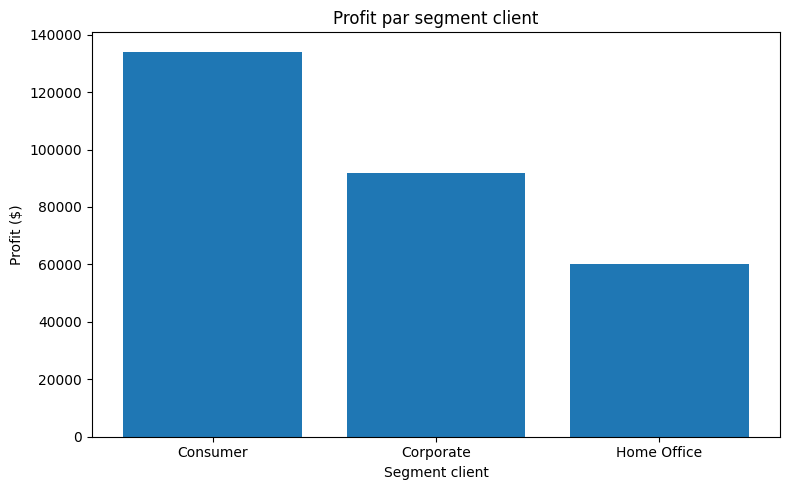

In [132]:
plt.figure(figsize=(8, 5))

plt.bar(
    segment_performance["Segment"],
    segment_performance["Profit"]
)

plt.title("Profit par segment client")
plt.xlabel("Segment client")
plt.ylabel("Profit ($)")

plt.tight_layout()
plt.savefig("../outputs/figures/profit_by_segment.png", dpi=300, bbox_inches="tight")
plt.show()

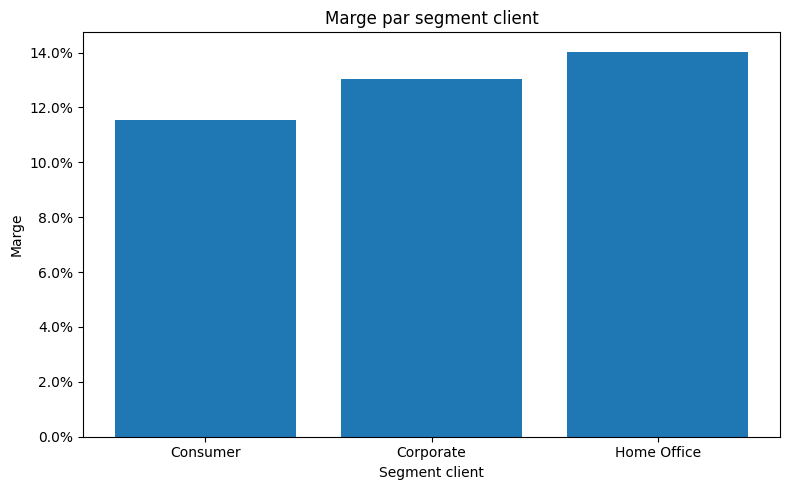

In [133]:
plt.figure(figsize=(8, 5))

plt.bar(
    segment_performance["Segment"],
    segment_performance["Margin"]
)

plt.title("Marge par segment client")
plt.xlabel("Segment client")
plt.ylabel("Marge")

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))

plt.tight_layout()
plt.savefig("../outputs/figures/margin_by_segment.png", dpi=300, bbox_inches="tight")
plt.show()

### Analyse des segments clients

Le segment `Consumer` est le principal contributeur à l'activité du magasin : il représente le plus grand nombre de clients, le plus grand nombre de commandes, le chiffre d'affaires le plus élevé et le profit total le plus important.

Cependant, le segment `Home Office` présente la meilleure rentabilité relative, avec une marge de 14,03 % et le panier moyen le plus élevé, à 472,67 $.

Ainsi, `Consumer` constitue le segment le plus important en volume, tandis que `Home Office` apparaît comme le segment le plus intéressant à développer en termes de rentabilité.

### 6.2 Clients générant le plus de chiffre d'affaires

In [134]:
top_customers_sales = (
    df_clean
    .groupby(["Customer ID", "Customer Name", "Segment"], as_index=False)
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Orders=("Order ID", "nunique")
    )
    .sort_values(by="Sales", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

top_customers_sales["Margin"] = (
    top_customers_sales["Profit"] / top_customers_sales["Sales"]
)

top_customers_sales

,Customer ID,Customer Name,Segment,Sales,Profit,Orders,Margin
0,SM-20320,Sean Miller,Home Office,25043.050,-1980.7393,5,-0.079093
1,TC-20980,Tamara Chand,Corporate,19052.218,8981.3239,5,0.471406
2,RB-19360,Raymond Buch,Consumer,15117.339,6976.0959,6,0.461463
3,TA-21385,Tom Ashbrook,Home Office,14595.620,4703.7883,4,0.322274
4,AB-10105,Adrian Barton,Consumer,14473.571,5444.8055,10,0.376190
5,KL-16645,Ken Lonsdale,Consumer,14175.229,806.8550,12,0.056920
6,SC-20095,Sanjit Chand,Consumer,14142.334,5757.4119,9,0.407105
7,HL-15040,Hunter Lopez,Consumer,12873.298,5622.4292,6,0.436751
8,SE-20110,Sanjit Engle,Consumer,12209.438,2650.6769,11,0.217101
9,CC-12370,Christopher Conant,Consumer,12129.072,2177.0493,5,0.179490


In [135]:
top_customers_sales_display = top_customers_sales.copy()

top_customers_sales_display["Sales"] = top_customers_sales_display["Sales"].map(lambda x: f"{x:,.2f} $")
top_customers_sales_display["Profit"] = top_customers_sales_display["Profit"].map(lambda x: f"{x:,.2f} $")
top_customers_sales_display["Margin"] = top_customers_sales_display["Margin"].map(lambda x: f"{x:.2%}")

top_customers_sales_display

,Customer ID,Customer Name,Segment,Sales,Profit,Orders,Margin
0,SM-20320,Sean Miller,Home Office,"25,043.05 $","-1,980.74 $",5,-7.91%
1,TC-20980,Tamara Chand,Corporate,"19,052.22 $","8,981.32 $",5,47.14%
2,RB-19360,Raymond Buch,Consumer,"15,117.34 $","6,976.10 $",6,46.15%
3,TA-21385,Tom Ashbrook,Home Office,"14,595.62 $","4,703.79 $",4,32.23%
4,AB-10105,Adrian Barton,Consumer,"14,473.57 $","5,444.81 $",10,37.62%
5,KL-16645,Ken Lonsdale,Consumer,"14,175.23 $",806.86 $,12,5.69%
6,SC-20095,Sanjit Chand,Consumer,"14,142.33 $","5,757.41 $",9,40.71%
7,HL-15040,Hunter Lopez,Consumer,"12,873.30 $","5,622.43 $",6,43.68%
8,SE-20110,Sanjit Engle,Consumer,"12,209.44 $","2,650.68 $",11,21.71%
9,CC-12370,Christopher Conant,Consumer,"12,129.07 $","2,177.05 $",5,17.95%


### 6.3 Clients générant le plus de profit

In [136]:
top_customers_profit = (
    df_clean
    .groupby(["Customer ID", "Customer Name", "Segment"], as_index=False)
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Orders=("Order ID", "nunique")
    )
    .sort_values(by="Profit", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

top_customers_profit["Margin"] = (
    top_customers_profit["Profit"] / top_customers_profit["Sales"]
)

top_customers_profit

,Customer ID,Customer Name,Segment,Sales,Profit,Orders,Margin
0,TC-20980,Tamara Chand,Corporate,19052.218,8981.3239,5,0.471406
1,RB-19360,Raymond Buch,Consumer,15117.339,6976.0959,6,0.461463
2,SC-20095,Sanjit Chand,Consumer,14142.334,5757.4119,9,0.407105
3,HL-15040,Hunter Lopez,Consumer,12873.298,5622.4292,6,0.436751
4,AB-10105,Adrian Barton,Consumer,14473.571,5444.8055,10,0.376190
5,TA-21385,Tom Ashbrook,Home Office,14595.620,4703.7883,4,0.322274
6,CM-12385,Christopher Martinez,Consumer,8954.020,3899.8904,4,0.435546
7,KD-16495,Keith Dawkins,Corporate,8181.256,3038.6254,12,0.371413
8,AR-10540,Andy Reiter,Consumer,6608.448,2884.6208,6,0.436505
9,DR-12940,Daniel Raglin,Home Office,8350.868,2869.0760,8,0.343566


In [137]:
top_customers_profit_display = top_customers_profit.copy()

top_customers_profit_display["Sales"] = top_customers_profit_display["Sales"].map(lambda x: f"{x:,.2f} $")
top_customers_profit_display["Profit"] = top_customers_profit_display["Profit"].map(lambda x: f"{x:,.2f} $")
top_customers_profit_display["Margin"] = top_customers_profit_display["Margin"].map(lambda x: f"{x:.2%}")

top_customers_profit_display

,Customer ID,Customer Name,Segment,Sales,Profit,Orders,Margin
0,TC-20980,Tamara Chand,Corporate,"19,052.22 $","8,981.32 $",5,47.14%
1,RB-19360,Raymond Buch,Consumer,"15,117.34 $","6,976.10 $",6,46.15%
2,SC-20095,Sanjit Chand,Consumer,"14,142.33 $","5,757.41 $",9,40.71%
3,HL-15040,Hunter Lopez,Consumer,"12,873.30 $","5,622.43 $",6,43.68%
4,AB-10105,Adrian Barton,Consumer,"14,473.57 $","5,444.81 $",10,37.62%
5,TA-21385,Tom Ashbrook,Home Office,"14,595.62 $","4,703.79 $",4,32.23%
6,CM-12385,Christopher Martinez,Consumer,"8,954.02 $","3,899.89 $",4,43.55%
7,KD-16495,Keith Dawkins,Corporate,"8,181.26 $","3,038.63 $",12,37.14%
8,AR-10540,Andy Reiter,Consumer,"6,608.45 $","2,884.62 $",6,43.65%
9,DR-12940,Daniel Raglin,Home Office,"8,350.87 $","2,869.08 $",8,34.36%


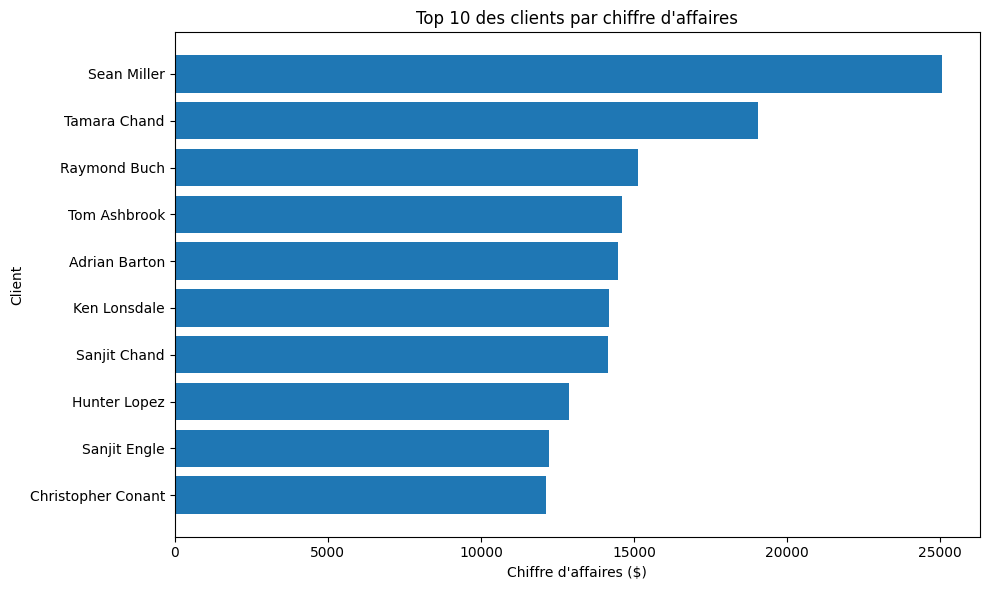

In [138]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_customers_sales["Customer Name"],
    top_customers_sales["Sales"]
)

plt.title("Top 10 des clients par chiffre d'affaires")
plt.xlabel("Chiffre d'affaires ($)")
plt.ylabel("Client")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("../outputs/figures/top_customers_sales.png", dpi=300, bbox_inches="tight")
plt.show()

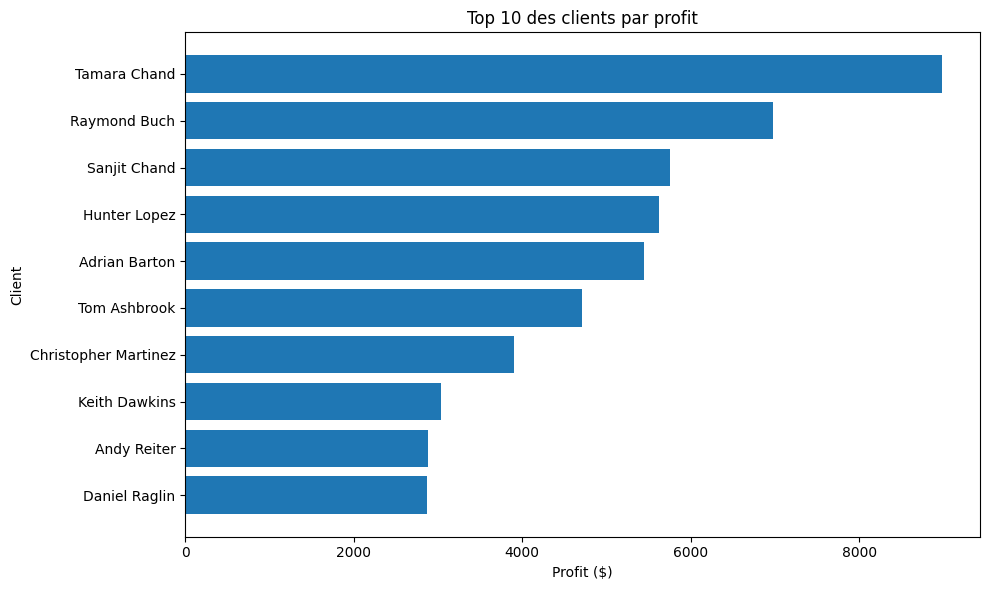

In [139]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_customers_profit["Customer Name"],
    top_customers_profit["Profit"]
)

plt.title("Top 10 des clients par profit")
plt.xlabel("Profit ($)")
plt.ylabel("Client")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("../outputs/figures/top_customers_profit.png", dpi=300, bbox_inches="tight")
plt.show()

### Analyse des meilleurs clients

Le classement des clients par chiffre d'affaires et le classement par profit ne sont pas identiques.

`Sean Miller` est le client qui génère le plus de chiffre d'affaires, avec 25 043,05 $, mais il est déficitaire pour l'entreprise, avec une perte de 1 980,74 $ et une marge de -7,91 %.

À l'inverse, `Tamara Chand`, deuxième en chiffre d'affaires, est le client le plus rentable avec 8 981,32 $ de profit et une marge de 47,14 %.

Cette analyse montre qu'un client générant beaucoup de ventes n'est pas nécessairement un client rentable. Pour piloter efficacement l'activité, il est donc indispensable de suivre à la fois le chiffre d'affaires et le profit par client.

## 7. Analyse géographique

### 7.1 Performance par région

In [140]:
region_performance = (
    df_clean
    .groupby("Region", as_index=False)
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Orders=("Order ID", "nunique"),
        Customers=("Customer ID", "nunique")
    )
)

region_performance["Margin"] = (
    region_performance["Profit"] / region_performance["Sales"]
)

region_performance = region_performance.sort_values(
    by="Sales",
    ascending=False
).reset_index(drop=True)

region_performance

,Region,Sales,Profit,Orders,Customers,Margin
0,West,725457.8245,108418.4489,1611,686,0.149448
1,East,678781.2400,91522.7800,1401,674,0.134834
2,Central,501239.8908,39706.3625,1175,629,0.079216
3,South,391721.9050,46749.4303,822,512,0.119343


In [141]:
region_display = region_performance.copy()

region_display["Sales"] = region_display["Sales"].map(lambda x: f"{x:,.2f} $")
region_display["Profit"] = region_display["Profit"].map(lambda x: f"{x:,.2f} $")
region_display["Margin"] = region_display["Margin"].map(lambda x: f"{x:.2%}")

region_display

,Region,Sales,Profit,Orders,Customers,Margin
0,West,"725,457.82 $","108,418.45 $",1611,686,14.94%
1,East,"678,781.24 $","91,522.78 $",1401,674,13.48%
2,Central,"501,239.89 $","39,706.36 $",1175,629,7.92%
3,South,"391,721.91 $","46,749.43 $",822,512,11.93%


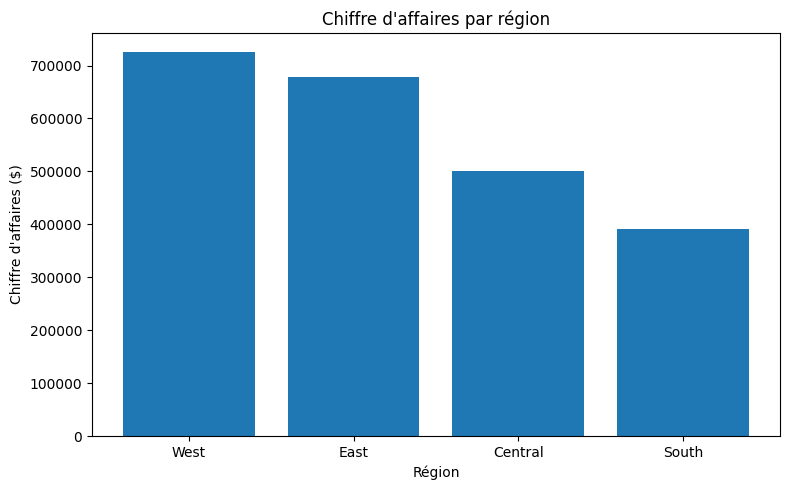

In [142]:
plt.figure(figsize=(8, 5))

plt.bar(
    region_performance["Region"],
    region_performance["Sales"]
)

plt.title("Chiffre d'affaires par région")
plt.xlabel("Région")
plt.ylabel("Chiffre d'affaires ($)")

plt.tight_layout()
plt.savefig("../outputs/figures/sales_by_region.png", dpi=300, bbox_inches="tight")
plt.show()

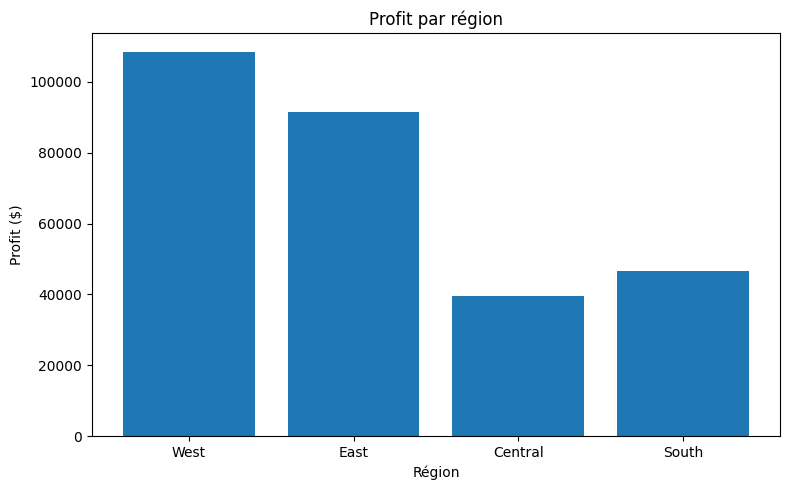

In [143]:
plt.figure(figsize=(8, 5))

plt.bar(
    region_performance["Region"],
    region_performance["Profit"]
)

plt.title("Profit par région")
plt.xlabel("Région")
plt.ylabel("Profit ($)")

plt.tight_layout()
plt.savefig("../outputs/figures/profit_by_region.png", dpi=300, bbox_inches="tight")
plt.show()

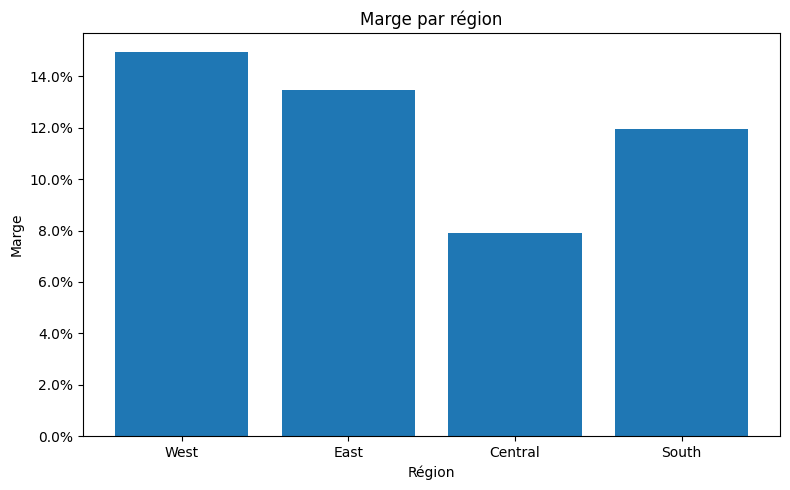

In [144]:
plt.figure(figsize=(8, 5))

plt.bar(
    region_performance["Region"],
    region_performance["Margin"]
)

plt.title("Marge par région")
plt.xlabel("Région")
plt.ylabel("Marge")

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))

plt.tight_layout()
plt.savefig("../outputs/figures/margin_by_region.png", dpi=300, bbox_inches="tight")
plt.show()

### Analyse géographique

La région `West` est la plus performante du dataset : elle génère le chiffre d'affaires le plus élevé, le profit le plus important et la meilleure marge.

La région `East` présente également de bons résultats, avec un niveau de ventes et de rentabilité proche de `West`.

L'analyse met aussi en évidence un écart entre volume d'activité et rentabilité : la région `Central` réalise davantage de chiffre d'affaires que `South`, mais génère moins de profit et affiche la marge la plus faible, à 7,92 %. Cela montre qu'une région peut vendre davantage tout en étant moins rentable.

## 8. Synthèse des résultats et recommandations business

### 8.1 Principaux constats

L'analyse des ventes retail met en évidence plusieurs enseignements clés :

1. Le magasin a généré un chiffre d'affaires total de 2,30 millions de dollars, pour un profit total de 286 397 dollars et une marge globale de 12,47 %.

2. Les produits qui génèrent le plus de chiffre d'affaires sont principalement des équipements à forte valeur unitaire, comme les copieurs et les systèmes de visioconférence. À l'inverse, les produits les plus vendus en quantité sont surtout des fournitures de bureau.

3. Les ventes progressent globalement sur la période étudiée, avec une année 2017 particulièrement performante. Une saisonnalité est visible : les mois de novembre, décembre et septembre sont les plus forts.

4. La catégorie `Technology` est la plus performante, à la fois en chiffre d'affaires et en profit. La catégorie `Furniture`, malgré un volume de ventes élevé, affiche une rentabilité très faible.

5. La faible rentabilité de `Furniture` s'explique principalement par les sous-catégories `Tables` et `Bookcases`, qui sont déficitaires. Ces deux sous-catégories présentent également les remises moyennes les plus élevées.

6. Le segment `Consumer` est le plus important en volume, mais le segment `Home Office` affiche la meilleure marge et le panier moyen le plus élevé.

7. Les clients qui génèrent le plus de chiffre d'affaires ne sont pas toujours les plus rentables. Par exemple, `Sean Miller` est le premier client en chiffre d'affaires, mais il génère une perte, tandis que `Tamara Chand` est le client le plus rentable.

8. La région `West` est la plus performante en chiffre d'affaires, profit et marge. À l'inverse, la région `Central` réalise un volume de ventes important mais présente la rentabilité la plus faible.

### 8.2 Recommandations business

À partir de ces constats, plusieurs actions peuvent être recommandées :

1. **Renforcer les stocks et les campagnes commerciales sur les produits à forte contribution**, notamment les équipements technologiques générant le plus de chiffre d'affaires.

2. **Préparer les périodes fortes en amont**, en particulier avant septembre, novembre et décembre, afin d'optimiser les stocks, les promotions et les ressources commerciales.

3. **Réviser la politique de remise sur les sous-catégories `Tables` et `Bookcases`**, qui cumulent remises élevées et pertes financières. Une réduction ou un meilleur encadrement des remises pourrait améliorer la rentabilité de `Furniture`.

4. **Ne pas piloter uniquement par le chiffre d'affaires**, mais intégrer systématiquement le profit et la marge dans les analyses produits, clients et régions.

5. **Développer des actions ciblées vers le segment `Home Office`**, qui présente la meilleure rentabilité et le panier moyen le plus élevé.

6. **Mettre en place un suivi spécifique des clients à fort chiffre d'affaires mais à faible rentabilité**, afin d'identifier les causes des pertes et d'ajuster les conditions commerciales.

7. **Analyser plus finement la région `Central`**, dont le niveau de ventes est correct mais dont la marge est la plus faible, afin de détecter d'éventuels problèmes de remises, de mix produits ou de coûts.

### 8.3 Conclusion

Cette analyse montre que la performance commerciale ne peut pas être évaluée uniquement à travers le chiffre d'affaires. Les dimensions de profitabilité, de saisonnalité, de segmentation client et de rentabilité géographique sont essentielles pour obtenir une vision complète de l'activité.

Le projet a permis d'identifier les produits, périodes, catégories, segments clients et régions les plus performants, mais aussi de détecter plusieurs points d'attention, notamment la faible rentabilité de certaines sous-catégories de `Furniture` et de la région `Central`.

Ces résultats peuvent servir de base à la création d'un tableau de bord de pilotage commercial et à la prise de décisions plus orientées vers la rentabilité.

## 9. Export des résultats

Les principaux tableaux d'analyse sont exportés au format CSV afin de conserver une trace des résultats et de faciliter leur réutilisation dans d'autres outils.

In [145]:
# Export des principaux résultats de l'analyse

kpis.to_csv("../outputs/results/kpis_summary.csv", index=False)

sales_by_year.to_csv("../outputs/results/sales_by_year.csv", index=False)
sales_by_month.to_csv("../outputs/results/sales_by_month.csv", index=False)
sales_by_year_month.to_csv("../outputs/results/sales_by_year_month.csv", index=False)

top_products_sales.to_csv("../outputs/results/top_products_by_sales.csv", index=False)
top_products_quantity.to_csv("../outputs/results/top_products_by_quantity.csv", index=False)

category_performance.to_csv("../outputs/results/category_performance.csv", index=False)
subcategory_performance.to_csv("../outputs/results/subcategory_performance.csv", index=False)
furniture_subcategories.to_csv("../outputs/results/furniture_subcategories.csv", index=False)
furniture_discount_analysis.to_csv("../outputs/results/furniture_discount_analysis.csv", index=False)

segment_performance.to_csv("../outputs/results/segment_performance.csv", index=False)

top_customers_sales.to_csv("../outputs/results/top_customers_by_sales.csv", index=False)
top_customers_profit.to_csv("../outputs/results/top_customers_by_profit.csv", index=False)

region_performance.to_csv("../outputs/results/region_performance.csv", index=False)